In [1]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from utils import *
from src.drd import AutoEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-18 09:42:15.576905: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763476935.588801  125632 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763476935.592627  125632 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763476935.602614  125632 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [2]:
PATH_PREFIX = "/shared/share_mala/irchang/drd"
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2):
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            # match training!
        bottleneck_activation=None
    )

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

### MNIST

In [4]:
mnist_tsne_res_dict = []
mnist_tsne_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in [    5,    11,    27,    62,   146,   341,   793,  1846,  4297]:
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/mnist/tsne_{perp}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_umap = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        mnist_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_umap, "split": "Train", "seed": s, "fixed_teacher": False})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s, "fixed_teacher": False})

        # student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/mnist/tsne_{perp}_{s}_fixed_teacher_ckpts/final.pt",
        #         input_dim=784,
        #         hidden_dims=[1000, 1000, 1000, 1000, 1000],
        #         latent_dim=2)
        
        # student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        # train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        # mnist_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": True})
        # for i in range(X.shape[0]):
        #     per_sample_recon_loss = np.mean((student_recon_tsne.detach().numpy()[i] - X[i])**2)
        #     mnist_tsne_per_sample_res_dict.append({"perplexity": perp, "recon_loss": per_sample_recon_loss, "split": "train", "seed": s, "fixed_teacher": True, "sample_idx": i})

        # x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        # test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        # mnist_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": True})
        # for i in range(X_test.shape[0]):
        #     per_sample_recon_loss = np.mean((x_test_recon.detach().numpy()[i] - X_test[i])**2)
        #     mnist_tsne_per_sample_res_dict.append({"perplexity": perp, "recon_loss": per_sample_recon_loss, "split": "test", "seed": s, "fixed_teacher": True, "sample_idx": i})

encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=1000, bias=True)
  (9): SELU()
  (10): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): S

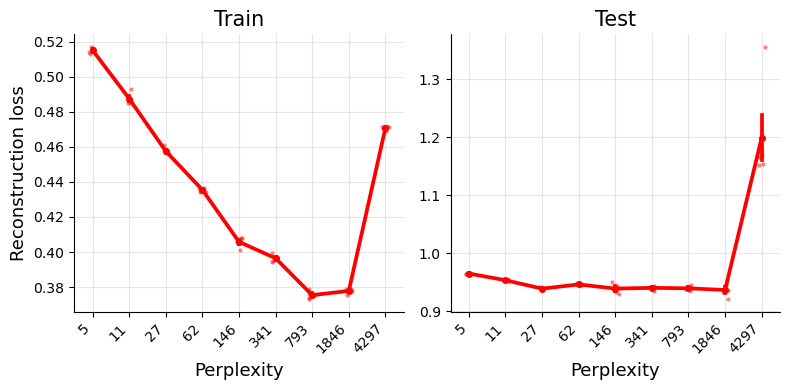

In [17]:
analysis = pd.DataFrame(mnist_tsne_res_dict)
analysis_per_sample = pd.DataFrame(mnist_tsne_per_sample_res_dict)
analysis.sort_values(by='perplexity', inplace=True)
# analysis_per_sample.sort_values(by='perplexity', inplace=True)

g = sns.FacetGrid(analysis, col="split",  height=4, sharey=False)
# train_split = analysis_per_sample[(analysis_per_sample.split == "train")]
# test_split = analysis_per_sample[(analysis_per_sample.split == "test")]

# sns.pointplot(data =  train_split, x="perplexity", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[2])
# sns.pointplot(data = test_split, x="perplexity", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[3])

g.map_dataframe(sns.pointplot, "perplexity", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "perplexity", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("Perplexity", "Reconstruction loss", fontsize=13)
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', size=10)
    ax.set_title(ax.get_title(), fontsize=15)
plt.tight_layout()

In [9]:
mnist_umap_res_dict = []
mnist_umap_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/umap2_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        mnist_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "Train", "seed": s})
        # for i in range(X.shape[0]):
        #     per_sample_recon_loss = np.mean((student_recon_tsne.detach().numpy()[i] - X[i])**2)
        #     mnist_umap_per_sample_res_dict.append({"n_neighbors": n, "recon_loss": per_sample_recon_loss, "split": "train", "seed": s, "sample_idx": i})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "Test", "seed": s})
        # for i in range(X_test.shape[0]):
        #     per_sample_recon_loss = np.mean((x_test_recon.detach().numpy()[i] - X_test[i])**2)
        #     mnist_umap_per_sample_res_dict.append({"n_neighbors": n, "recon_loss": per_sample_recon_loss, "split": "test", "seed": s, "sample_idx": i})

        # student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/mnist/umap_{n}_0.1_{s}_fixed_teacher_ckpts/final.pt",
        #         input_dim=784,
        #         hidden_dims=[1000, 1000, 1000, 1000, 1000],
        #         latent_dim=2)
        
        # student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        # train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        # mnist_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": True})

        # x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        # test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        # mnist_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": True})
        

encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=1000, bias=True)
  (9): SELU()
  (10): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): S

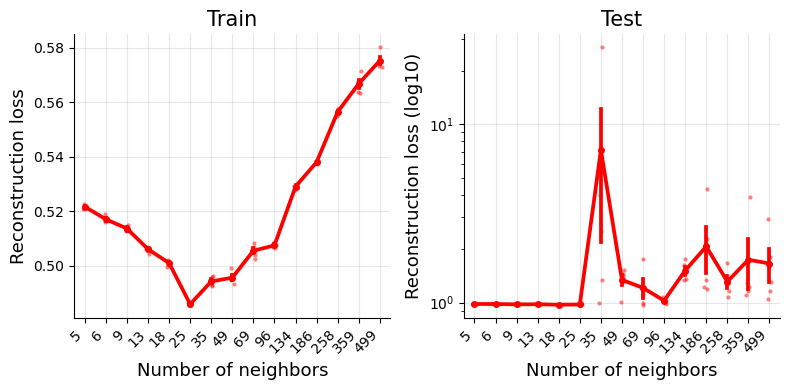

In [11]:
analysis = pd.DataFrame(mnist_umap_res_dict)
# analysis_per_sample = pd.DataFrame(mnist_umap_per_sample_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
# analysis.loc[analysis.split =="test", 'recon_loss'] = np.pow(analysis.loc[analysis.split =="test", 'recon_loss'], 1/2)
# analysis_per_sample.sort_values(by='n_neighbors', inplace=True)

g = sns.FacetGrid(analysis, col="split",  sharey=False, height=4)
# train_split = analysis_per_sample[(analysis_per_sample.split == "train")]
# test_split = analysis_per_sample[(analysis_per_sample.split == "test")]

# sns.pointplot(data =  train_split, x="n_neighbors", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[0])
# sns.pointplot(data = test_split, x="n_neighbors", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[1])

g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("Number of neighbors", "Reconstruction loss", fontsize=13)
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(ax.get_title(), fontsize=15)
g.axes.flat[1].set_yscale('log', base=10)
g.axes.flat[1].set_ylabel('Reconstruction loss (log10)', fontsize=13)
plt.tight_layout()

In [6]:
mnist_spectral_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in [2,3] + list(np.unique(np.logspace(np.log10(5), np.log10(200), 15).astype(int))) :
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        mnist_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "train", "seed": s})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "test", "seed": s})

encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=1000, bias=True)
  (9): SELU()
  (10): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): S

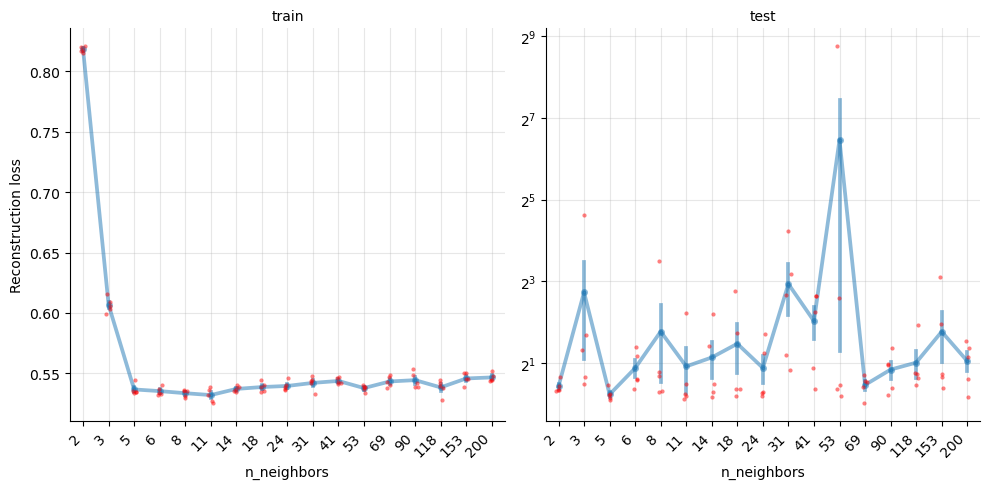

In [30]:
analysis = pd.DataFrame(mnist_spectral_res_dict)

g = sns.FacetGrid(analysis, col="split", sharey='col', height=5, sharex=True)
g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, alpha=0.5)
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("n_neighbors", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
g.axes.flat[1].set_yscale('log', base=2)
plt.tight_layout()

In [39]:
mnist_pca_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    student_pca = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/pca2_{s}_ckpts/final.pt",
            input_dim=784,
            hidden_dims=[1000, 1000, 1000, 1000, 1000],
            latent_dim=2)
    
    student_recon_pca, student_embed_pca = student_pca(torch.tensor(X, dtype=torch.float32))
    train_recon_pca = np.mean((student_recon_pca.detach().numpy() - X)**2)
    mnist_pca_res_dict.append({"recon_loss": train_recon_tsne, "split": "train", "seed": s})

    x_test_recon, _ = student_pca(torch.tensor(X_test, dtype=torch.float32))
    test_recon_pca = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    mnist_pca_res_dict.append({"recon_loss": test_recon_tsne, "split": "test", "seed": s})

encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=1000, bias=True)
  (9): SELU()
  (10): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): S

In [ ]:
tsne_analysis = pd.DataFrame(mnist_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.fixed_teacher==True) & (tsne_analysis.split=='test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(mnist_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='test'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
spectral_analysis = pd.DataFrame(mnist_spectral_res_dict)
spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='test'), :]
spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
pca_analysis = pd.DataFrame(mnist_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='test'), :]

In [41]:
tsne_analysis_agg.loc[tsne_analysis_agg.recon_loss.idxmin(), 'perplexity'], umap_analysis_agg.loc[umap_analysis_agg.recon_loss.idxmin(), 'n_neighbors'], spectral_analysis_agg.loc[spectral_analysis_agg.recon_loss.idxmin(), 'n_neighbors']

(np.int64(793), np.int64(18), np.int64(5))

In [44]:
tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == 5, ['recon_loss', 'seed']]
tsne_best['method'] = 'TSNE(perplexity=5)'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == 18, ['recon_loss', 'seed']]
umap_best['method'] = 'UMAP(n_neighbors=18)'
spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == 5, ['recon_loss', 'seed']]
spectral_best['method'] = 'Spectral(n_neighbors=5)'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, spectral_best, pca_best])

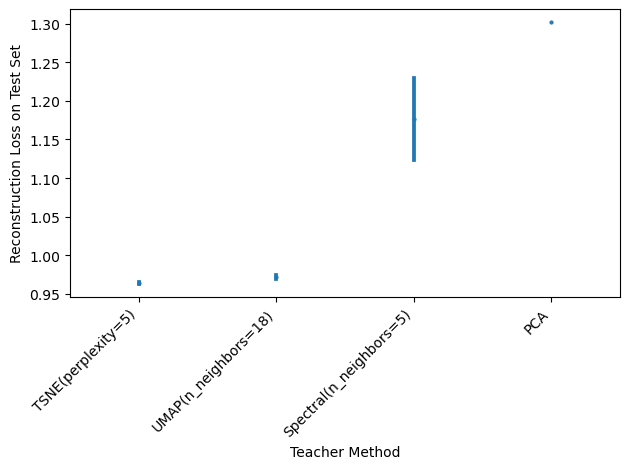

In [ ]:
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylabel("Reconstruction Loss on Test Set")
plt.xlabel("Teacher Method")
sns.
plt.show()

### Hydra

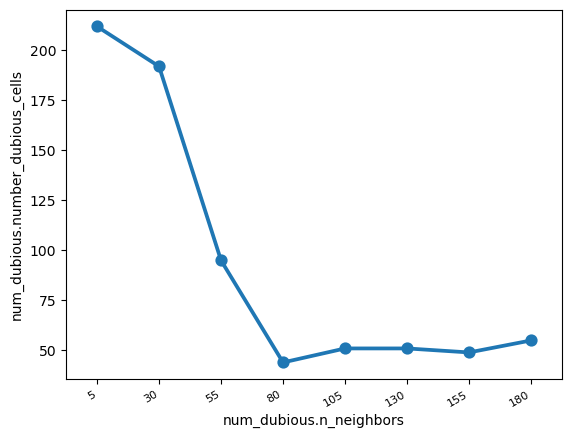

In [15]:
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'tmp/hydra_scdeed_umap.csv', index_col=0)
sns.pointplot(data=scdeed_analysis[scdeed_analysis['num_dubious.min.dist'] == 0.1], x='num_dubious.n_neighbors', y='num_dubious.number_dubious_cells')
plt.xticks(rotation=30, fontsize=8, ha='right');

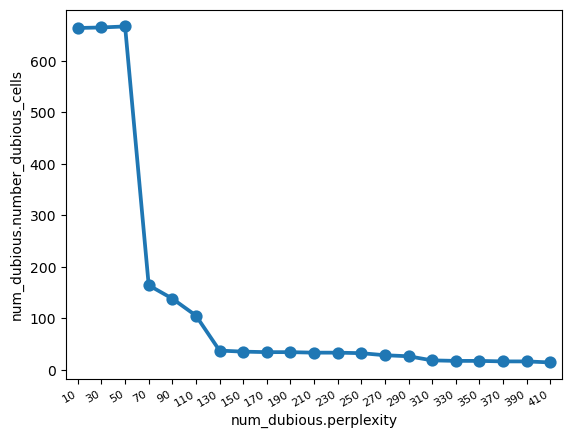

In [19]:
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'tmp/hydra_scdeed_tsne.csv', index_col=0)
sns.pointplot(data=scdeed_analysis, x='num_dubious.perplexity', y='num_dubious.number_dubious_cells')
plt.xticks(rotation=30, fontsize=8, ha='right');

In [ ]:
hydra_tsne_res_dict = []
hydra_tsne_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        # student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/hydra/tsne_{perp}_{s}_ckpts/final.pt",
        #         input_dim=500,
        #         hidden_dims=[309, 1792, 1792, 1792],
        #         latent_dim=2)
        
        # student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        # train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        # hydra_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": False})

        # x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        # test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        # hydra_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": False})

        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/hydra/tsne_{perp}_{s}_fixed_teacher_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        hydra_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "Train", "seed": s})
        # for i in range(X.shape[0]):
        #     per_sample_recon_loss = np.mean((student_recon_tsne.detach().numpy()[i] - X[i])**2)
        #     hydra_tsne_per_sample_res_dict.append({"perplexity": perp, "recon_loss": per_sample_recon_loss, "split": "train", "seed": s, "fixed_teacher": True, "sample_idx": i})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        hydra_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s})
        # for i in range(X_test.shape[0]):
        #     per_sample_recon_loss = np.mean((x_test_recon.detach().numpy()[i] - X_test[i])**2)
        #     hydra_tsne_per_sample_res_dict.append({"perplexity": perp, "recon_loss": per_sample_recon_loss, "split": "test", "seed": s, "fixed_teacher": True, "sample_idx": i})

encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=500, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (

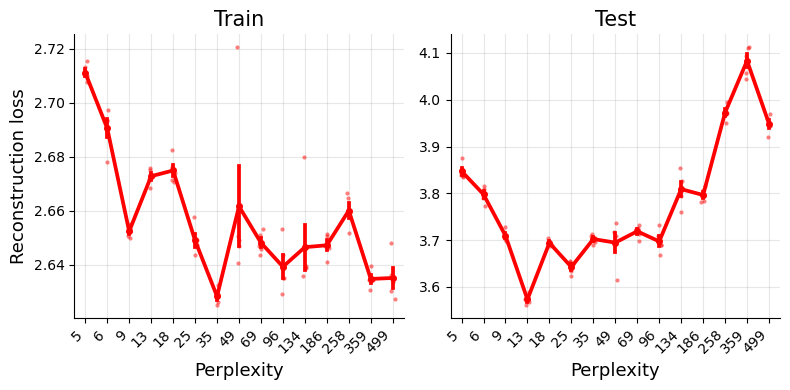

In [8]:
analysis = pd.DataFrame(hydra_tsne_res_dict)
analysis_per_sample = pd.DataFrame(hydra_tsne_per_sample_res_dict)
analysis.sort_values(by='perplexity', inplace=True)
# analysis_per_sample.sort_values(by='perplexity', inplace=True)
analysis.loc[analysis.split == "test", 'split'] = 'Test'
analysis.loc[analysis.split == "train", 'split'] = 'Train'

g = sns.FacetGrid(analysis, col="split",sharey='col', height=4)
# train_split = analysis_per_sample[(analysis_per_sample.split == "train")]
# test_split = analysis_per_sample[(analysis_per_sample.split == "test")]

# sns.pointplot(data =  train_split, x="perplexity", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[0])
# sns.pointplot(data = test_split, x="perplexity", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[1])

g.map_dataframe(sns.pointplot, "perplexity", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "perplexity", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("Perplexity", "Reconstruction loss", fontsize=13)
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(ax.get_title(), fontsize=15)
plt.tight_layout()

In [47]:
hydra_umap_res_dict = []
hydra_umap_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        # student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/hydra/umap_{n}_0.1_{s}_ckpts/final.pt",
        #         input_dim=500,
        #         hidden_dims=[309, 1792, 1792, 1792],
        #         latent_dim=2)
        
        # student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        # train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        # hydra_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": False})

        # x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        # test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        # hydra_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": False})

        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/hydra/umap_{n}_0.1_{s}_fixed_teacher_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        hydra_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "Train", "seed": s, "fixed_teacher": True})
        # for i in range(X.shape[0]):
        #     per_sample_recon_loss = np.mean((student_recon_tsne.detach().numpy()[i] - X[i])**2)
        #     hydra_umap_per_sample_res_dict.append({"n_neighbors": n, "recon_loss": per_sample_recon_loss, "split": "train", "seed": s, "fixed_teacher": True, "sample_idx": i})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        hydra_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "Test", "seed": s, "fixed_teacher": True})
        # for i in range(X_test.shape[0]):
        #     per_sample_recon_loss = np.mean((x_test_recon.detach().numpy()[i] - X_test[i])**2)
        #     hydra_umap_per_sample_res_dict.append({"n_neighbors": n, "recon_loss": per_sample_recon_loss, "split": "test", "seed": s, "fixed_teacher": True, "sample_idx": i})

encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=500, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (

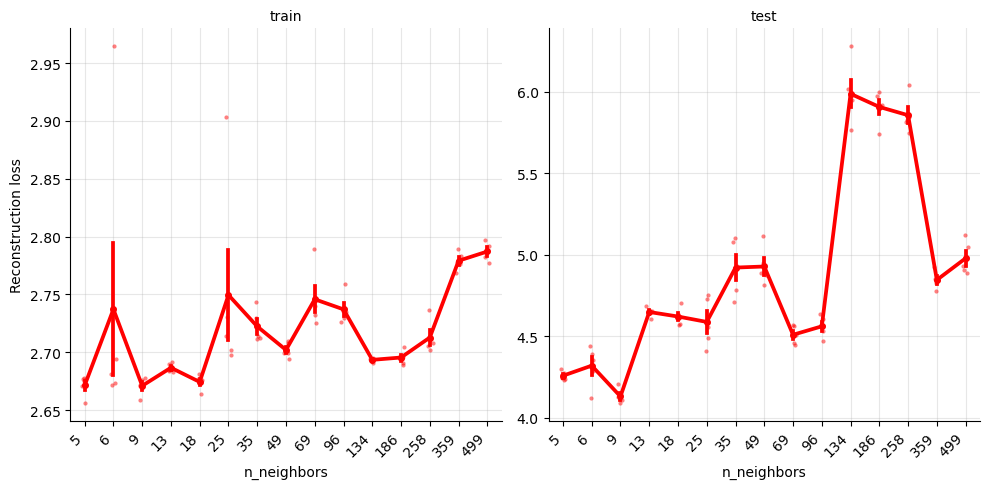

In [50]:
analysis = pd.DataFrame(hydra_umap_res_dict)
analysis_per_sample = pd.DataFrame(hydra_umap_per_sample_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
# analysis_per_sample.sort_values(by='n_neighbors', inplace=True)

g = sns.FacetGrid(analysis, col="split", sharey='col', height=5, sharex=True)
# train_split = analysis_per_sample[(analysis_per_sample.split == "train")]
# test_split = analysis_per_sample[(analysis_per_sample.split == "test")]

# sns.pointplot(data =  train_split, x="n_neighbors", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[0])
# sns.pointplot(data = test_split, x="n_neighbors", y="recon_loss", hue="seed", alpha=0.3, dodge=True, linestyles="none", palette="crest", legend=False, ax = g.axes.flat[1])

g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("n_neighbors", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

In [4]:
hydra_spectral_res_dict = []
hydra_spectral_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(200), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/hydra_spectral_{n}_0_train.npy")
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed_tsne.detach().numpy()) ** 2)
        print(f"distill loss {train_distill}")
        # if train_distill <= 9e-6:
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        hydra_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "Train", "seed": s, "fixed_teacher": True})
        # for i in range(X.shape[0]):
        #     per_sample_recon_loss = np.mean((student_recon_tsne.detach().numpy()[i] - X[i])**2)
        #     hydra_spectral_per_sample_res_dict.append({"n_neighbors": n, "recon_loss": per_sample_recon_loss, "split": "train", "seed": s, "fixed_teacher": True, "sample_idx": i})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        hydra_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "Test", "seed": s, "fixed_teacher": True})
        # for i in range(X_test.shape[0]):
        #     per_sample_recon_loss = np.mean((x_test_recon.detach().numpy()[i] - X_test[i])**2)
        #     hydra_spectral_per_sample_res_dict.append({"n_neighbors": n, "recon_loss": per_sample_recon_loss, "split": "test", "seed": s, "fixed_teacher": True, "sample_idx": i})
    # else:
        # print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=500, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
distill loss 1.2451662051462643e-05
encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=179

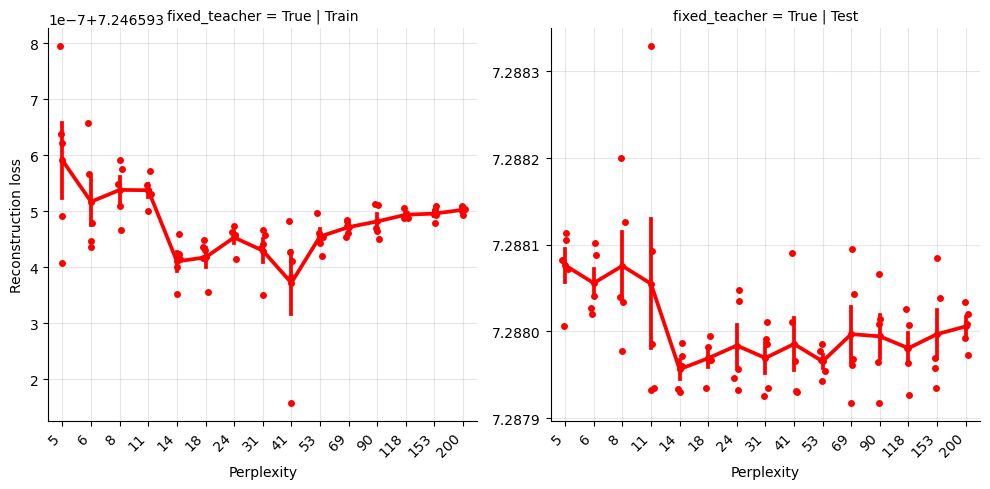

In [6]:
analysis = pd.DataFrame(hydra_spectral_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)

g = sns.FacetGrid(analysis, col="split", row="fixed_teacher", sharey='col', height=5)

g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red")
g.set_axis_labels("Perplexity", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

### Cortical

In [28]:
tasic_tsne_res_dict = []
tasic_tsne_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        # student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/cortical/tsne_{perp}_{s}_ckpts/final.pt",
        #         input_dim=1000,
        #         hidden_dims=[309, 1792, 1792, 1792],
        #         latent_dim=2)
        # student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        # train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        # tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": False})

        # x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        # test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        # tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": False})

        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/cortical/tsne_{perp}_{s}_fixed_teacher_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "Train", "seed": s, "fixed_teacher": True})
        # for i in range(X.shape[0]):
        #     per_sample_recon_loss = np.mean((student_recon_tsne.detach().numpy()[i] - X[i])**2)
        #     tasic_tsne_per_sample_res_dict.append({"perplexity": perp, "recon_loss": per_sample_recon_loss, "split": "train", "seed": s, "fixed_teacher": True, "sample_idx": i})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s, "fixed_teacher": True})
        # for i in range(X_test.shape[0]):
        #     per_sample_recon_loss = np.mean((x_test_recon.detach().numpy()[i] - X_test[i])**2)
        #     tasic_tsne_per_sample_res_dict.append({"perplexity": perp, "recon_loss": per_sample_recon_loss, "split": "test", "seed": s, "fixed_teacher": True, "sample_idx": i})

encoder layers: Sequential(
  (0): Linear(in_features=1000, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=1000, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=1000, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)


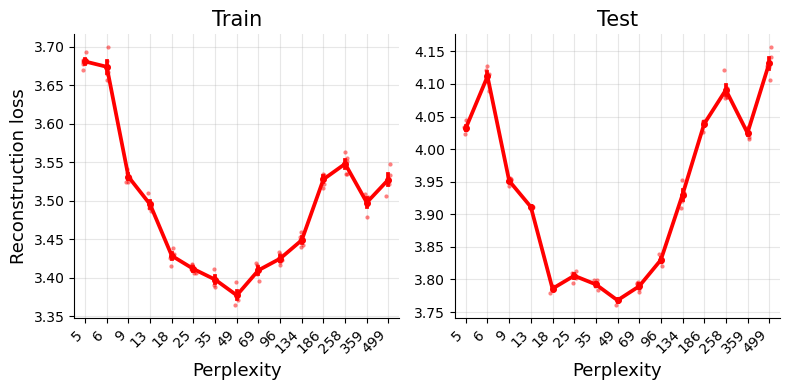

In [30]:
analysis = pd.DataFrame(tasic_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)

g = sns.FacetGrid(analysis, col="split",sharey='col', height=4)
g.map_dataframe(sns.pointplot, "perplexity", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "perplexity", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("Perplexity", "Reconstruction loss", fontsize=13)
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(ax.get_title(), fontsize=15)
plt.tight_layout()

In [8]:
tasic_umap_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        student_umap = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/cortical/umap_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2)
        
        student_recon_umap, student_embed_umap = student_umap(torch.tensor(X, dtype=torch.float32))
        train_recon_umap = np.mean((student_recon_umap.detach().numpy() - X)**2)
        tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_umap, "split": "train", "seed": s, "fixed_teacher": False})

        x_test_recon, _ = student_umap(torch.tensor(X_test, dtype=torch.float32))
        test_recon_umap = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_umap, "split": "test", "seed": s, "fixed_teacher": False})

        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"results/chkpt/cortical/umap_{n}_0.1_{s}_fixed_teacher_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": True})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": True})

encoder layers: Sequential(
  (0): Linear(in_features=1000, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=1000, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=1000, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)


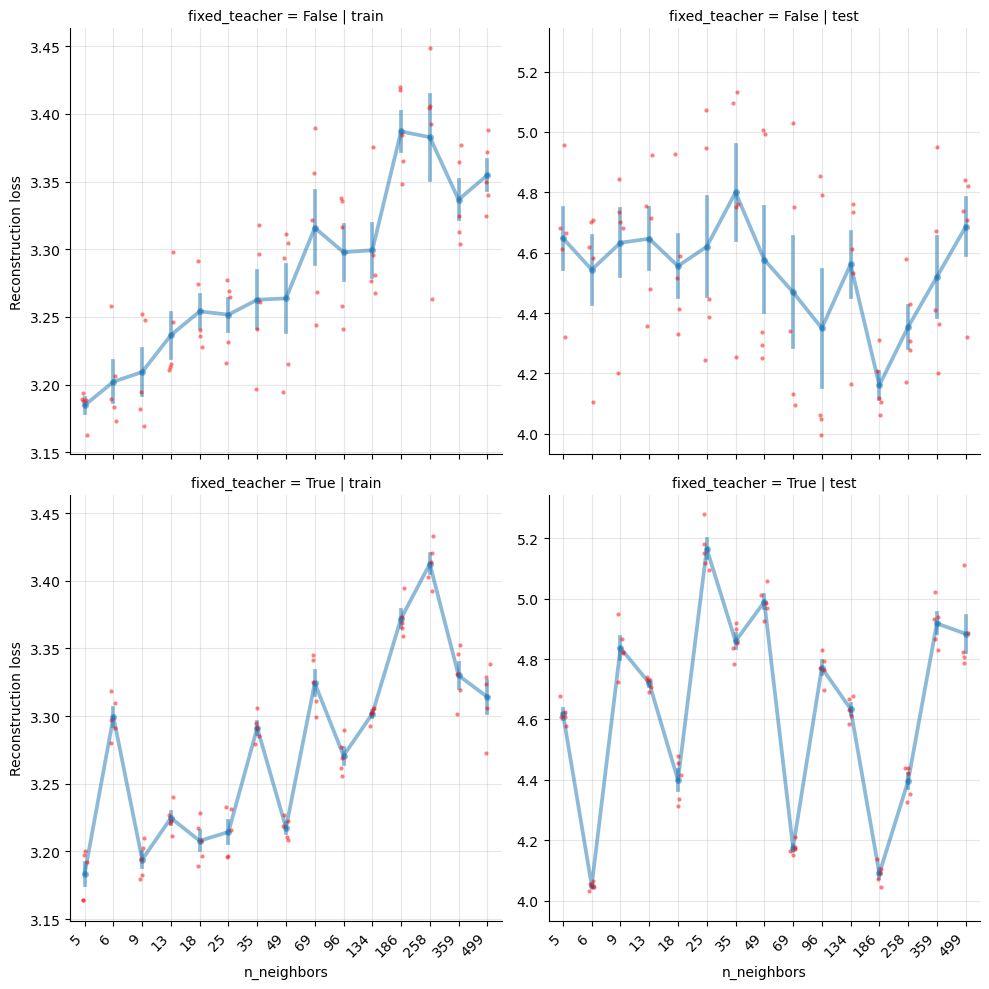

In [10]:
analysis = pd.DataFrame(tasic_umap_res_dict)

g = sns.FacetGrid(analysis, col="split", row="fixed_teacher", sharey='col', height=5, sharex=True)
g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, alpha=0.5)
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("n_neighbors", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()

### Macaque

In [3]:
macaque_tsne_res_dict = []
macaque_tsne_per_sample_res_dict = []
X, X_test, y, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(3), np.log10(250), 15).astype(int)):
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/macaque/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=100,
                hidden_dims=[700] * 15,
                latent_dim=2)
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        macaque_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "train", "seed": s})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        macaque_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "test", "seed": s})

encoder layers: Sequential(
  (0): Linear(in_features=100, out_features=700, bias=True)
  (1): SELU()
  (2): Linear(in_features=700, out_features=700, bias=True)
  (3): SELU()
  (4): Linear(in_features=700, out_features=700, bias=True)
  (5): SELU()
  (6): Linear(in_features=700, out_features=700, bias=True)
  (7): SELU()
  (8): Linear(in_features=700, out_features=700, bias=True)
  (9): SELU()
  (10): Linear(in_features=700, out_features=700, bias=True)
  (11): SELU()
  (12): Linear(in_features=700, out_features=700, bias=True)
  (13): SELU()
  (14): Linear(in_features=700, out_features=700, bias=True)
  (15): SELU()
  (16): Linear(in_features=700, out_features=700, bias=True)
  (17): SELU()
  (18): Linear(in_features=700, out_features=700, bias=True)
  (19): SELU()
  (20): Linear(in_features=700, out_features=700, bias=True)
  (21): SELU()
  (22): Linear(in_features=700, out_features=700, bias=True)
  (23): SELU()
  (24): Linear(in_features=700, out_features=700, bias=True)
  (25): S

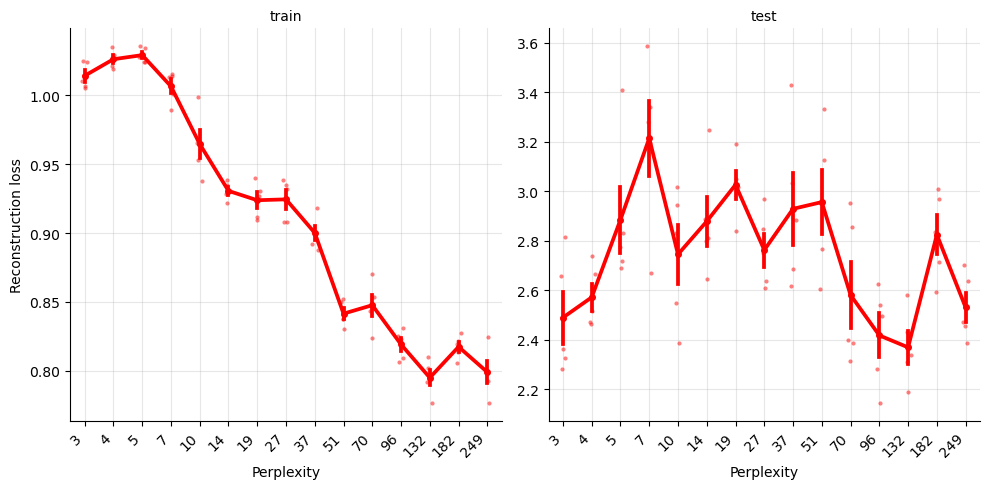

In [4]:
analysis = pd.DataFrame(macaque_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)

g = sns.FacetGrid(analysis, col="split", sharey=False, height=5)
g.map_dataframe(sns.pointplot, "perplexity", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "perplexity", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("Perplexity", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

### PANCAN

In [12]:
pancan_umap_res_dict = []
X, X_test, y, y_test = load_and_split("gene_cancer", test_size=0.2, seed=0, labels=True)
for s in range(2):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        student_tsne = load_trained_ae(Path('/tmp') / f"results/chkpt/gene_cancer/umap_{n}_0.1_{s}_fixed_teacher_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        pancan_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": True})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        pancan_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": True})

encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=20531, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bi

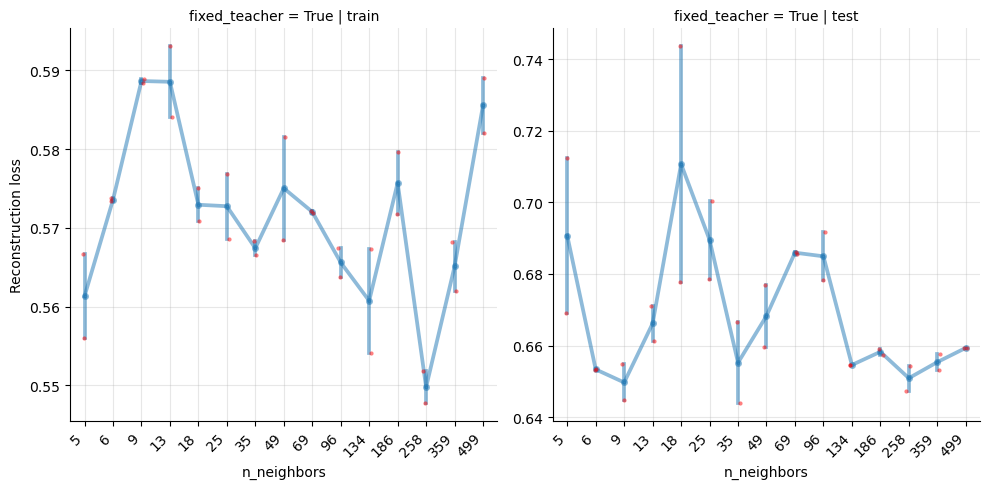

In [14]:
analysis = pd.DataFrame(pancan_umap_res_dict)

g = sns.FacetGrid(analysis, col="split", row="fixed_teacher", sharey='col', height=5)
g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, alpha=0.5)
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("n_neighbors", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

In [9]:
pancan_spectral_res_dict = []
X, X_test, y, y_test = load_and_split("gene_cancer", test_size=0.2, seed=0, labels=True)
for s in range(1):
    for n in np.unique(np.logspace(np.log10(5), np.log10(100), 15).astype(int)):
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        pancan_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon_tsne, "split": "train", "seed": s, "fixed_teacher": True})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        pancan_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon_tsne, "split": "test", "seed": s, "fixed_teacher": True})

encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=20531, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bi

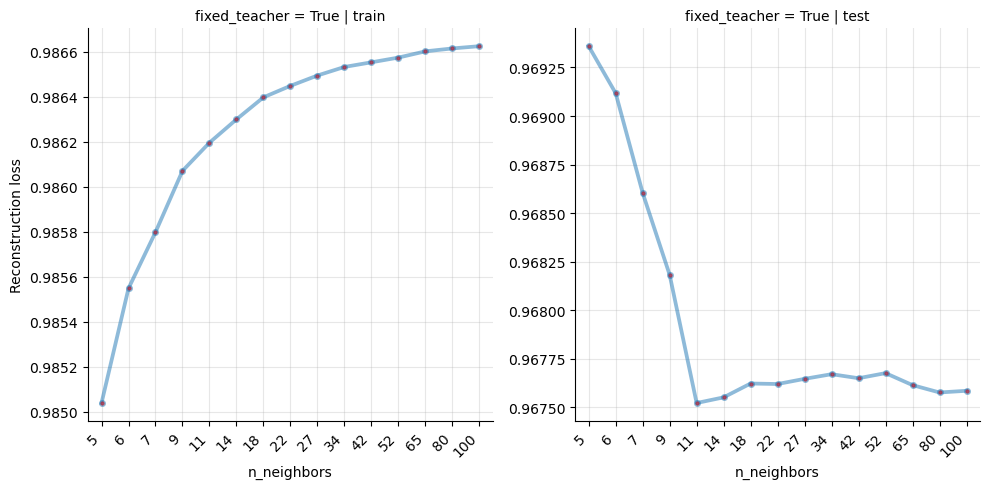

In [11]:
analysis = pd.DataFrame(pancan_spectral_res_dict)

g = sns.FacetGrid(analysis, col="split", row="fixed_teacher", sharey='col', height=5)
g.map_dataframe(sns.pointplot, "n_neighbors", "recon_loss", errorbar="se",markersize= 3, alpha=0.5)
g.map_dataframe(sns.stripplot, "n_neighbors", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("n_neighbors", "Reconstruction loss")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

### Astro

In [ ]:
astro_tsne_res_dict = []
X, X_test, y, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(3), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/astro_tsne_{perp}_0_train.npy")
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/astro/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=19,
                hidden_dims=[256, 256,256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256],
                latent_dim=2)
        
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed_tsne.detach().numpy()) ** 2)
        if train_distill <= 9e-6:
            train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "Train", "seed": s, "fixed_teacher": True})

            x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
            test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s, "fixed_teacher": True})
        else:
            print(f"Skipping perplexity {perp} seed {s} due to distillation loss {train_distill}")

encoder layers: Sequential(
  (0): Linear(in_features=19, out_features=256, bias=True)
  (1): SELU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): SELU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): SELU()
  (6): Linear(in_features=256, out_features=256, bias=True)
  (7): SELU()
  (8): Linear(in_features=256, out_features=256, bias=True)
  (9): SELU()
  (10): Linear(in_features=256, out_features=256, bias=True)
  (11): SELU()
  (12): Linear(in_features=256, out_features=256, bias=True)
  (13): SELU()
  (14): Linear(in_features=256, out_features=256, bias=True)
  (15): SELU()
  (16): Linear(in_features=256, out_features=256, bias=True)
  (17): SELU()
  (18): Linear(in_features=256, out_features=256, bias=True)
  (19): SELU()
  (20): Linear(in_features=256, out_features=256, bias=True)
  (21): SELU()
  (22): Linear(in_features=256, out_features=256, bias=True)
  (23): SELU()
  (24): Linear(in_features=256, out_features=256, bias=True)
  (25): SE

In [8]:
!ls /shared/share_mala/irchang/drd/tmp_results/chkpt/astro

tsne2_115_0_ckpts  tsne2_18_3_ckpts   tsne2_38_0_ckpts	 tsne2_6_0_ckpts
tsne2_115_1_ckpts  tsne2_18_4_ckpts   tsne2_38_1_ckpts	 tsne2_6_1_ckpts
tsne2_115_2_ckpts  tsne2_240_0_ckpts  tsne2_38_2_ckpts	 tsne2_6_2_ckpts
tsne2_115_3_ckpts  tsne2_240_1_ckpts  tsne2_38_3_ckpts	 tsne2_6_3_ckpts
tsne2_115_4_ckpts  tsne2_240_2_ckpts  tsne2_38_4_ckpts	 tsne2_6_4_ckpts
tsne2_12_0_ckpts   tsne2_240_3_ckpts  tsne2_4_0_ckpts	 tsne2_80_0_ckpts
tsne2_12_1_ckpts   tsne2_240_4_ckpts  tsne2_4_1_ckpts	 tsne2_80_1_ckpts
tsne2_12_2_ckpts   tsne2_26_0_ckpts   tsne2_4_2_ckpts	 tsne2_80_2_ckpts
tsne2_12_3_ckpts   tsne2_26_1_ckpts   tsne2_499_0_ckpts  tsne2_80_3_ckpts
tsne2_12_4_ckpts   tsne2_26_2_ckpts   tsne2_499_1_ckpts  tsne2_80_4_ckpts
tsne2_167_0_ckpts  tsne2_26_3_ckpts   tsne2_499_2_ckpts  tsne2_8_0_ckpts
tsne2_167_1_ckpts  tsne2_26_4_ckpts   tsne2_499_3_ckpts  tsne2_8_1_ckpts
tsne2_167_2_ckpts  tsne2_3_0_ckpts    tsne2_499_4_ckpts  tsne2_8_2_ckpts
tsne2_167_3_ckpts  tsne2_346_0_ckpts  tsne2_55_0_ckpts	 t

In [27]:
analysis = pd.DataFrame(astro_tsne_res_dict)
analysis[analysis.perplexity==4]

,perplexity,recon_loss,split,seed,fixed_teacher
2,4,0.354979,train,0,True
3,4,0.736049,test,0,True
30,4,0.365365,train,1,True
31,4,0.731201,test,1,True
58,4,0.356424,train,2,True
59,4,0.759430,test,2,True
84,4,0.363135,train,3,True
85,4,0.741824,test,3,True
110,4,0.349115,train,4,True
111,4,0.791573,test,4,True


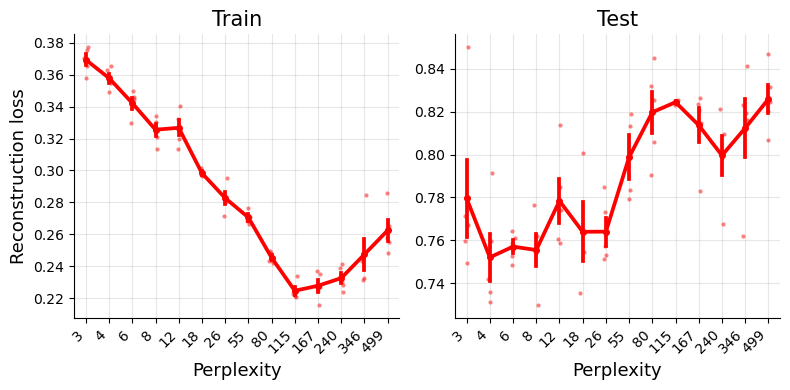

In [29]:
analysis = pd.DataFrame(astro_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)
analysis.loc[analysis.split == "test", 'split'] = 'Test'
analysis.loc[analysis.split == "train", 'split'] = 'Train'

g = sns.FacetGrid(analysis, col="split",sharey='col', height=4)
g.map_dataframe(sns.pointplot, "perplexity", "recon_loss", errorbar="se",markersize= 3, color="red")
g.map_dataframe(sns.stripplot, "perplexity", "recon_loss", color="red",size= 3, alpha=0.5)
g.set_axis_labels("Perplexity", "Reconstruction loss", fontsize=13)
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(ax.get_title(), fontsize=15)
plt.tight_layout()